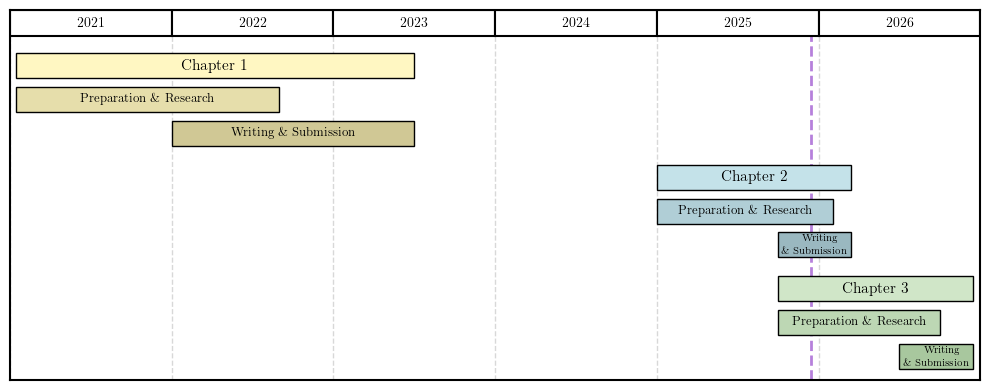

In [54]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# ------------------------------------------------------------
# Helper for easy date creation
# ------------------------------------------------------------
def d(y, m=1, day=1):
    return dt.date(y, m, day)

# ------------------------------------------------------------
# Exact chapter colors from your LaTeX definitions
# ------------------------------------------------------------
chapter1 = "#FFF7C2"   # RowYellow  (Chapter 1)
chapter2 = "#C4E2E9"   # RowBlue    (Chapter 2)
chapter3 = "#D0E6C8"   # RowGreen   (Chapter 3)

# Slightly darker variants for "Preparation & Research" and "Writing & Submission"
prep1   = "#E6DEAB"
write1  = "#D0C895"

prep2   = "#B0CED6"
write2  = "#9AB8C0"

prep3   = "#BDD7B4"
write3  = "#A8C79E"

# Softer magenta, more in line with the pastel palette
today_color = "#984BCC"

# ------------------------------------------------------------
# Task definitions
# ------------------------------------------------------------
tasks = [
    # ---------- Chapter 1 ----------
    dict(label="Chapter 1",
         start=d(2021, 1, 15), end=d(2023, 7, 1),
         y=6.9, height=0.85, color=chapter1, fontsize=11),

    dict(label=r"Preparation $\&$ Research",
         start=d(2021, 1, 15), end=d(2022, 9, 1),
         y=5.75, height=0.85, color=prep1, fontsize=9),

    dict(label=r"Writing $\&$ Submission",
         start=d(2022, 1, 1), end=d(2023, 7, 1),
         y=4.6, height=0.85, color=write1, fontsize=9),

    # ---------- Chapter 2 ----------
    dict(label="Chapter 2",
         start=d(2025, 1, 1), end=d(2026, 3, 15),
         y=3.1, height=0.85, color=chapter2, fontsize=11),

    dict(label=r"Preparation $\&$ Research",
         start=d(2025, 1, 1), end=d(2026, 2, 1),
         y=1.95, height=0.85, color=prep2, fontsize=9),

    dict(label=r"Writing \\ [-3pt]$\&$ Submission",
         start=d(2025, 10, 1), end=d(2026, 3, 15),
         y=0.8, height=0.85, color=write2, fontsize=7),

    # ---------- Chapter 3 ----------
    dict(label="Chapter 3",
         start=d(2025, 10, 1), end=d(2026, 12, 15),
         y=-0.7, height=0.85, color=chapter3, fontsize=11),

    dict(label=r"Preparation $\&$ Research",
         start=d(2025, 10, 1), end=d(2026, 10, 1),
         y=-1.85, height=0.85, color=prep3, fontsize=9),

    dict(label=r"Writing \\ [-3pt]$\&$ Submission",
         start=d(2026, 7, 1), end=d(2026, 12, 15),
         y=-3.0, height=0.85, color=write3, fontsize=7),
]

# Convert dates to matplotlib float numbers
for t in tasks:
    t["start_num"] = mdates.date2num(t["start"])
    t["end_num"] = mdates.date2num(t["end"])
    t["duration"] = t["end_num"] - t["start_num"]

# ------------------------------------------------------------
# Create figure and axis
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_facecolor("white")

# Spines: frame on three sides, no extra line at the very top
for side in ["left", "right", "bottom"]:
    ax.spines[side].set_linewidth(1.5)
    ax.spines[side].set_visible(True)
ax.spines["top"].set_linewidth(1.5)

# ------------------------------------------------------------
# X-axis: keep year locator for gridlines, but hide ticks and labels
# ------------------------------------------------------------
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Light vertical grid at each year (behind everything)
ax.grid(axis="x", which="major", color="gray", linestyle="--", linewidth=1, zorder=0, alpha=0.3)

# Hide tick marks and labels while keeping the locator for the grid
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# ------------------------------------------------------------
# Draw magenta "today" line FIRST so it sits behind bars
# ------------------------------------------------------------
today = d(2025, 12, 15)
ax.axvline(mdates.date2num(today), color=today_color, linewidth=2, ls='--', alpha=0.7)

# ------------------------------------------------------------
# Year header boxes (sit above the grid and magenta line)
# ------------------------------------------------------------
years = [2021, 2022, 2023, 2024, 2025, 2026]
year_y_bottom = 7.9
year_h = 0.9

for yr in years:
    start = d(yr, 1, 1)
    end   = d(yr+1, 1, 1) if yr != years[-1] else d(yr, 12, 31)
    x0 = mdates.date2num(start)
    x1 = mdates.date2num(end)
    w = x1 - x0

    rect = Rectangle(
        (x0, year_y_bottom),
        w, year_h,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=2,
    )
    ax.add_patch(rect)
    ax.text(x0 + w/2, year_y_bottom + year_h/2, str(yr),
            ha="center", va="center", fontsize=10, zorder=3)

# ------------------------------------------------------------
# Draw horizontal bars + labels (above line & grid)
# ------------------------------------------------------------
for t in tasks:
    ax.barh(
        t["y"], t["duration"],
        left=t["start_num"], height=t["height"],
        color=t["color"], edgecolor="black", zorder=3
    )
    ax.text(
        t["start_num"] + t["duration"]/2,
        t["y"],
        t["label"],
        ha="center", va="center",
        fontsize=t["fontsize"],
        clip_on=True,
        zorder=4,
    )

# ------------------------------------------------------------
# Limits & y-axis formatting
# ------------------------------------------------------------
ax.set_xlim(d(2021, 1, 1), d(2026, 12, 31))
ax.set_yticks([])

# Top of axis exactly at top of year boxes so no extra line above them
ax.set_ylim(-3.8, year_y_bottom + year_h)

# Display figure
plt.tight_layout()
plt.show()

# Save figure
fig.savefig("thesis_timeline.png", bbox_inches="tight", dpi=300)
